# Lab 4 - Part 1
## KNN Classification on Breast Cancer Dataset

Name:
Reg No:
Class: MCA

## Task 1: Data Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

%matplotlib inline

In [2]:
df = pd.read_csv("brca.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")])
df.columns = [c.replace("x.", "") if c != "y" else c for c in df.columns]

print(df.shape)
df.head()

(569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
print(df.isnull().sum().sum())
print(df.duplicated().sum())

0
0


No missing values and no duplicate rows in the dataset.

In [4]:
df["target"] = df["y"].map({"M": 0, "B": 1})
print(df["y"].value_counts())

X = df.drop(columns=["y", "target"])
y = df["target"].values
print(X.shape[1], "features")

y
B    357
M    212
Name: count, dtype: int64
30 features


Dataset has 569 rows and 30 features. Out of 569 samples 357 are Benign and 212 are Malignant, so it is a bit imbalanced towards Benign.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Why scaling is needed:** KNN uses distance between points to find neighbours. Some features like area_mean go up to hundreds while features like smoothness_mean are less than 1. If we do not scale, area_mean alone will decide the distance and the small value features will not matter at all. StandardScaler makes every feature have mean 0 and std 1 so all features get equal importance.

## Task 2: Train-Test Split Analysis

In [6]:
for name, ts in [("80:20", 0.20), ("70:30", 0.30), ("90:10", 0.10)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=ts, random_state=1, stratify=y)
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    print(name, "Train:", X_tr.shape[0], "Test:", X_te.shape[0], "Accuracy:", round(acc, 4))

80:20 Train: 455 Test: 114 Accuracy: 0.9737
70:30 Train: 398 Test: 171 Accuracy: 0.9649
90:10 Train: 512 Test: 57 Accuracy: 0.9825


Observation: 90:10 split gave the highest accuracy (0.9825) but the test set is only 57 samples so one or two wrong predictions change the score a lot. 70:30 has the biggest test set (171) so its accuracy number is more trustworthy even though it is the lowest here. 80:20 is a good middle ground, so this split is used for the rest of the lab.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=1, stratify=y)

## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic K

In [8]:
n_train = X_train.shape[0]
k_heuristic = int(round(np.sqrt(n_train)))
if k_heuristic % 2 == 0:
    k_heuristic += 1
print("n =", n_train, " heuristic K = round(sqrt(n)) =", k_heuristic)

n = 455  heuristic K = round(sqrt(n)) = 21


### 3.2 Model Training with K +/- 5

In [9]:
k_range = range(k_heuristic - 5, k_heuristic + 6)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)
    print("K =", k, " Accuracy =", round(acc, 4))

best_k_split = list(k_range)[int(np.argmax(accuracies))]
print("Best K in this range:", best_k_split)

K = 16  Accuracy = 0.9649
K = 17  Accuracy = 0.9561
K = 18  Accuracy = 0.9737
K = 19  Accuracy = 0.9561
K = 20  Accuracy = 0.9561
K = 21  Accuracy = 0.9561
K = 22  Accuracy = 0.9561
K = 23  Accuracy = 0.9561
K = 24  Accuracy = 0.9561
K = 25  Accuracy = 0.9561
K = 26  Accuracy = 0.9561
Best K in this range: 18


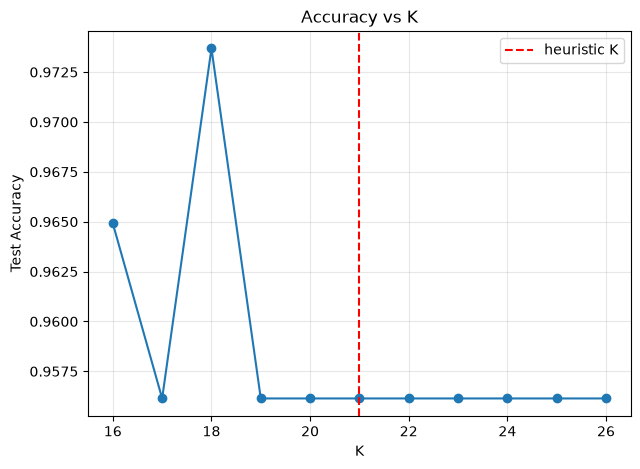

In [10]:
plt.figure(figsize=(7,5))
plt.plot(list(k_range), accuracies, marker="o")
plt.axvline(k_heuristic, color="red", linestyle="--", label="heuristic K")
plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("outputs/task3_accuracy_vs_k.png")
plt.show()

Accuracy goes up and down as K changes, there is no smooth pattern in this narrow range. The best result in this range is at K=18. The heuristic value (K=21) is close to this but not exactly the best, so heuristic is only a good starting point, not the final answer.

### 3.3 Distance Metrics

**Euclidean Distance:** d = sqrt(sum((p_i - q_i)^2)). This is the straight line distance between two points. It works well when the features are continuous and on the same scale, which is our case after StandardScaler, since it treats all directions equally.

**Manhattan Distance:** d = sum(|p_i - q_i|). This adds up the absolute difference in each feature, like moving along grid lines instead of a straight line. It is useful in high dimensional data and is less affected by a single large outlier since the differences are not squared.

### Decision Boundary for different K (using PCA to reduce to 2D)

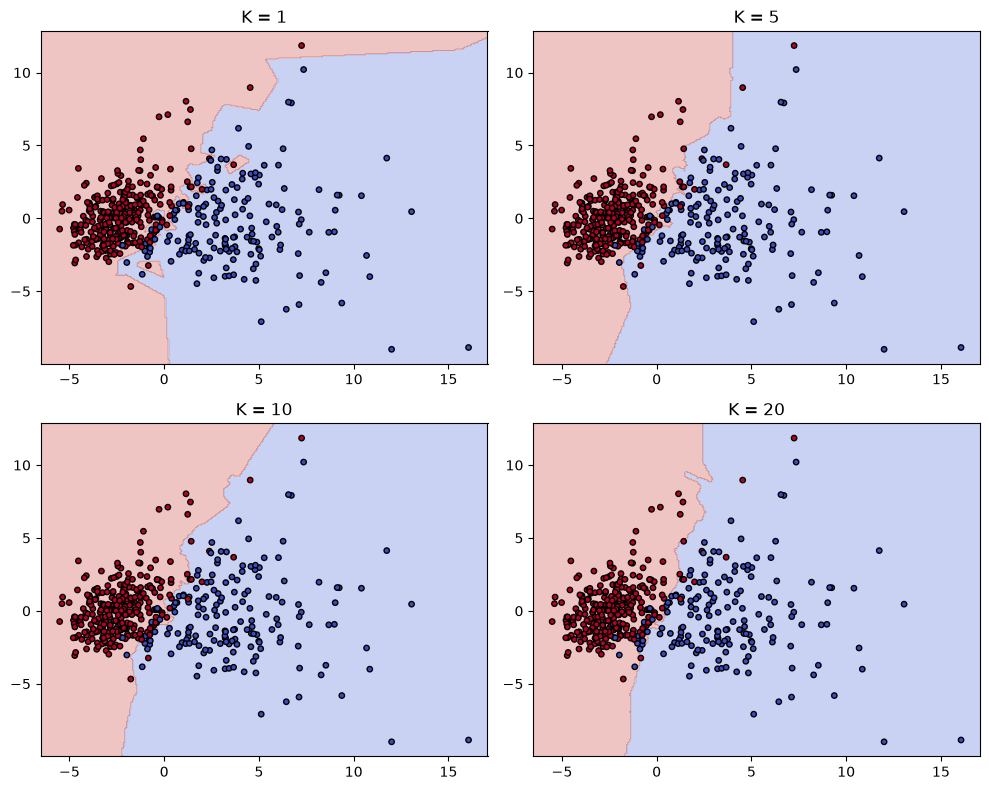

In [11]:
pca = PCA(n_components=2, random_state=1)
X_train_2d = pca.fit_transform(X_train)

k_list = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1, 300),
    np.linspace(X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1, 300)
)

for ax, k in zip(axes.ravel(), k_list):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_2d, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_train_2d[:,0], X_train_2d[:,1], c=y_train, cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(f"K = {k}")

plt.tight_layout()
plt.savefig("outputs/task3_decision_boundary.png")
plt.show()

In this dataset the two classes are already quite well separated in the top 2 PCA components, so the boundary does not change drastically across K. But there is a visible difference: at K=1 there is a small jagged pocket/tongue near the bottom of the boundary (around PC1=0, PC2=-3 to -5) which is the model reacting to individual nearby points. As K increases to 5, 10 and 20, that small pocket disappears and the boundary line becomes straighter and smoother, since the prediction is now based on a bigger neighbourhood of points instead of just the closest ones.

## Task 4: Cross Validation

In [12]:
cv_k_range = range(1, 31)
cv5_scores = []
cv10_scores = []

for k in cv_k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    cv5 = cross_val_score(model, X_scaled, y, cv=StratifiedKFold(5, shuffle=True, random_state=1))
    cv10 = cross_val_score(model, X_scaled, y, cv=StratifiedKFold(10, shuffle=True, random_state=1))
    cv5_scores.append(cv5.mean())
    cv10_scores.append(cv10.mean())

best_k_cv5 = list(cv_k_range)[int(np.argmax(cv5_scores))]
best_k_cv10 = list(cv_k_range)[int(np.argmax(cv10_scores))]

print("Best K (5-fold CV):", best_k_cv5, "accuracy =", round(max(cv5_scores),4))
print("Best K (10-fold CV):", best_k_cv10, "accuracy =", round(max(cv10_scores),4))

Best K (5-fold CV): 11 accuracy = 0.9719
Best K (10-fold CV): 11 accuracy = 0.9754


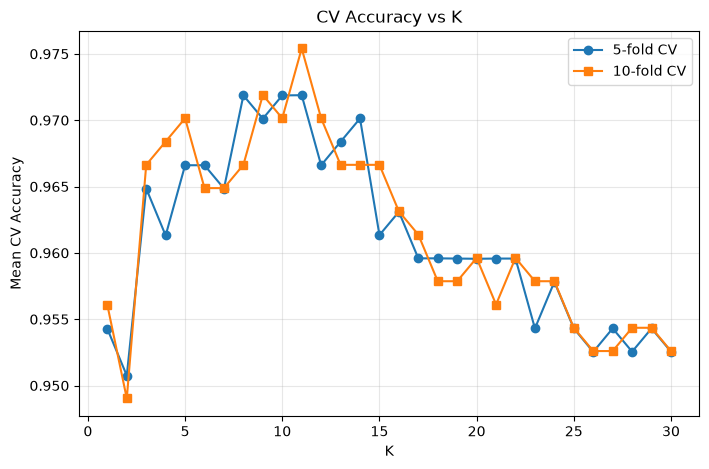

In [13]:
plt.figure(figsize=(8,5))
plt.plot(list(cv_k_range), cv5_scores, marker="o", label="5-fold CV")
plt.plot(list(cv_k_range), cv10_scores, marker="s", label="10-fold CV")
plt.xlabel("K")
plt.ylabel("Mean CV Accuracy")
plt.title("CV Accuracy vs K")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("outputs/task4_cv_accuracy_vs_k.png")
plt.show()

Both 5-fold and 10-fold CV agree on the best K here, which is K=11. This is more believable than the single 80:20 split result (K=18) because CV runs the model on many different train/test combinations and averages the score, so it is not affected by one lucky or unlucky split.

In [14]:
final_k = best_k_cv10
print("Heuristic K       :", k_heuristic)
print("Best K, 80:20 split:", best_k_split)
print("Best K, 5-fold CV  :", best_k_cv5)
print("Best K, 10-fold CV :", best_k_cv10)
print("Final K chosen     :", final_k)

Heuristic K       : 21
Best K, 80:20 split: 18
Best K, 5-fold CV  : 11
Best K, 10-fold CV : 11
Final K chosen     : 11


Final K is taken from the 10-fold CV result since cross validation is more reliable than a single split.

## Task 5: Classification Evaluation

In [15]:
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))
print(cm)

Accuracy : 0.9561
Precision: 0.9351
Recall   : 1.0
F1 Score : 0.9664
[[37  5]
 [ 0 72]]


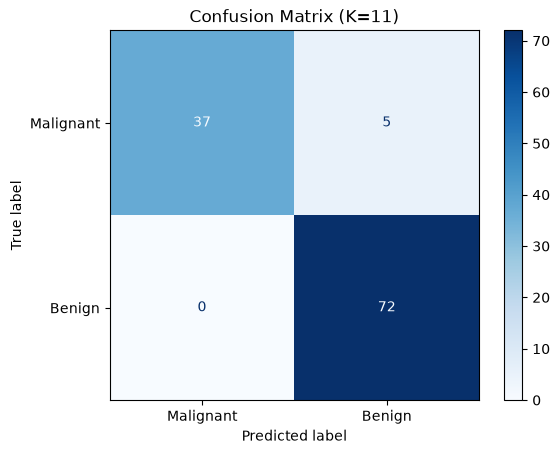

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant","Benign"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (K={final_k})")
plt.savefig("outputs/task5_confusion_matrix.png")
plt.show()

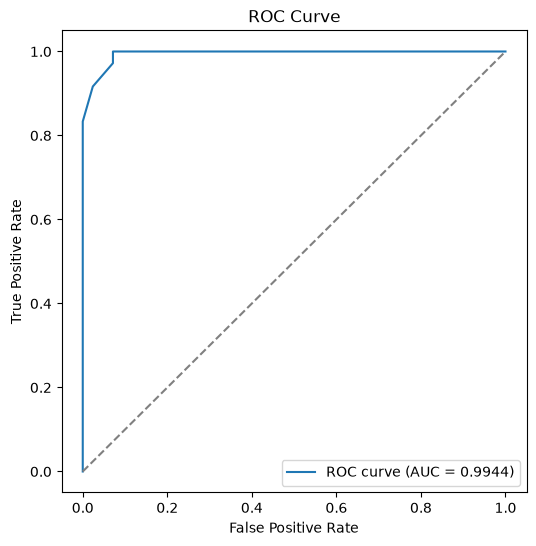

ROC-AUC: 0.9944


In [17]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("outputs/task5_roc_curve.png")
plt.show()

print("ROC-AUC:", round(roc_auc,4))

With K=11 the model gets 0.9561 accuracy, 0.9351 precision, 1.0 recall, 0.9664 F1 and 0.9944 ROC-AUC.

Here class 1 is Benign, so by default sklearn calculates precision and recall with respect to Benign. Recall = 1.0 means every actual Benign patient was correctly identified as Benign, no healthy case was wrongly flagged.

But looking at the confusion matrix directly: out of 42 actual Malignant cases, 37 were predicted correctly and 5 were wrongly predicted as Benign. These 5 are false negatives for cancer, which is the risky kind of mistake in this problem, even though the headline recall number looks perfect because it is measured on the Benign class. This shows why just reading one metric (Recall of the positive class as sklearn defines it) is not enough, the confusion matrix needs to be checked to know what is really happening for each class. ROC-AUC of 0.9944 still shows the model separates the two classes very well overall.

## Task 6: Comparative Study with Regression (Lab 3 Integration)

| Regression (Lab 3) | Classification (this lab) |
|---|---|
| MAE | Accuracy |
| MSE | Precision |
| RMSE | Recall |
| R2 Score | F1 Score, Confusion Matrix, ROC-AUC |

**Error-based vs Decision-based evaluation:** Regression metrics tell us how far off a predicted number is from the actual number, the error can be small or big in magnitude. Classification metrics tell us whether a predicted label is right or wrong, and on top of that they tell us what kind of mistake was made (false positive or false negative), which a regression error number cannot show.

**R2 Score vs Accuracy:** Both give a single score between 0 and 1 to say how good the model is overall. R2 tells how much of the variance in a continuous target is explained, Accuracy tells what fraction of labels were predicted correctly. Both can hide problems, R2 can hide a few large residuals and Accuracy can hide poor performance on the minority class.

**RMSE vs F1 Score:** RMSE squares the errors so large errors get punished more, and it stays in the same unit as the target. F1 Score instead balances Precision and Recall into one number, which is useful specially when one class is rare, like Malignant cases here.

**MAE vs Confusion Matrix:** MAE gives one average error value for all predictions. Confusion Matrix does not reduce everything to one number, it shows exactly how many TP, TN, FP, FN happened, so it gives much more detail about where the model is going wrong.

**Continuous tasks vs Classification tasks:** In regression the question is "how close is my predicted number to the real number", so evaluation is on a continuous scale. In classification the question is "did I pick the right class" and also "what type of mistake did I make", specially important when one type of mistake (like missing a cancer case) is more costly than the other.

### Inference

Regression metrics like MAE, MSE and RMSE measure how far the predicted number is from the actual number, so they describe the size of the error. Classification metrics like Accuracy, Precision, Recall and F1 measure whether the predicted class label itself is correct, so they describe decision correctness rather than error size.

Accuracy alone is not enough for medical diagnosis because the dataset here is imbalanced (357 Benign vs 212 Malignant) and because not all mistakes cost the same. A model can show high accuracy while still missing actual Malignant cases, and missing a cancer case is far more dangerous than a false alarm.

Recall and ROC-AUC matter more in healthcare because Recall (for the Malignant class specifically) shows how many actual cancer cases were correctly caught, and ROC-AUC shows how well the model separates the two classes across all thresholds, not just one cutoff point. In this lab the model's Recall of 1.0 was for the Benign class, but the confusion matrix showed 5 out of 42 actual Malignant cases were missed, which is the more important number to watch in a cancer detection setting. This is exactly why accuracy or a single recall number is not enough on its own.

Overall, regression evaluation is about how close a continuous prediction is to the true value, while classification evaluation is about whether the correct category was chosen and what kind of error was made. Both need more than one metric to get a full picture, RMSE alongside R2 in regression, and Recall alongside Accuracy in classification.

## Task 7: Analytical Questions

**1) Why is KNN called a lazy learning algorithm?**
KNN does not build any model while training, it just stores the training data as it is. All the work (measuring distance, checking nearest points) happens only when a new point needs to be predicted. Since the actual "learning" is delayed to prediction time, it is called a lazy learner, unlike algorithms like Logistic Regression that build a model during training.

**2) Why is feature scaling required in KNN?**
KNN decides the nearest neighbours based on distance. If one feature has a much bigger range than others, like area_mean vs smoothness_mean here, that one feature will control the distance and the rest will barely matter. Scaling brings every feature to the same range so all of them contribute fairly.

**3) Explain heuristic K selection using the sqrt(n) rule.**
This rule says a reasonable starting K is the square root of the number of training samples. It is just a rule of thumb to get a starting point that is not too small (noisy) and not too big (oversmoothed). It should always be checked against nearby values and cross validation, since it is not always the best K, as also seen in this lab where heuristic K was 21 but the actual best K turned out to be 11.

**4) Why is cross-validation more reliable than a single train-test split?**
A single split depends on which samples randomly land in the test set, an easy or a hard split can give a misleading score. Cross validation runs the same model over several different folds and averages the accuracy, so the final result is not dependent on one random split and gives a more stable estimate.

**5) How does K affect the bias-variance trade-off?**
Small K (like K=1) has low bias but high variance, it fits closely to individual points and noise, so it can overfit. Large K has high bias but low variance, it averages over many neighbours so the model becomes too general and can underfit. A good K is somewhere in between.

**6) Why is recall more important than accuracy in cancer prediction?**
In cancer detection, missing an actual Malignant case (false negative) can cost a life, while a false positive just leads to another test being done. Accuracy can still look high even if a model misses several malignant cases, specially when the dataset is imbalanced. Recall specifically tells how many real malignant cases were correctly found, so it matters more here.

**7) What is the limitation of very large K values?**
When K becomes very large, the neighbourhood used for prediction includes points that are far away and not really similar, making the decision boundary too smooth. This causes the model to underfit and lose accuracy near the class boundaries, and in the extreme case where K equals the whole training set size, every prediction would just become the majority class.

## Conclusion

- Heuristic K (sqrt(n)) gave K=21, but after checking K+/-5 on the split and confirming with 5-fold and 10-fold cross validation, the best K came out as 11.
- Train-test split ratio does affect the result, 90:10 showed the highest accuracy but on a very small test set (57 samples) so it is less trustworthy than 80:20.
- The final KNN model (K=11) gave Accuracy 0.9561, Precision 0.9351, Recall 1.0, F1 0.9664 and ROC-AUC 0.9944 on the test set, showing strong performance, specially in catching Benign cases correctly.
- Regression metrics (Lab 3) measure the size of numeric error, classification metrics (this lab) measure whether the class label is correct and what type of error occurred, both are needed to fully judge a model but they are answering different questions.